## Characterizing an Exoplanet Candidate from TESS B Light-Curve Data

## Overview

This project uses real light-curve data from **TESS B** to detect and characterize a transiting exoplanet candidate.  

### Main goals
- load and inspect the TESS light curve
- identify repeated transit events
- measure the orbital period, transit depth, and transit duration
- estimate the planet radius and orbital distance
- interpret the system using orbital geometry and differential equations

### Mathematical focus
This project intentionally incorporates material from advanced calculus:

- **Calculus 3:** vector-valued orbital motion, projected sky-plane distance, and orbital geometry
- **Calculus 4:** differential equations for gravitational motion and numerical integration using RK4

### Dataset
The data file used here is `TESSB_lc.dat`, which contains:
- time in Barycentric Julian Date
- detrended normalized flux
- flux uncertainty

Because the flux is already detrended in the provided dataset, this project applies only a very light normalization step before the transit analysis.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import differential_evolution
from scipy.ndimage import median_filter

plt.rcParams["figure.figsize"] = (10, 5) #plot width for easy viewing
plt.rcParams["axes.grid"] = True #grid lines default

## 1. Physical equations used in this project

### Transit depth
The fractional loss of light during a transit is

$$\delta = \left(\frac{R_p}{R_{\star}}\right)^2$$

so the planet radius is

$$R_p = R_{\star} \sqrt{\delta}$$

### Transit timing model
If a planet transits repeatedly with period `P`, then the center times follow

$$t_n = t_0 + nP$$

where:
- $t_n$ is the time of the nth transit
- $t0$ is a reference transit center
- $P$ is the orbital period

### Kepler's Third Law
For a circular orbit,

$$a^3 = \frac{G M_{\star} P^2}{4\pi^2}$$

so

$$a = \left(\frac{G M_{\star} P^2}{4\pi^2}\right)^{1/3}$$

### Calculus 3: vector orbit model
A circular orbit can be written as

$$\mathbf{r}(t) = \langle x(t), y(t) \rangle$$

with

$$x(t) = a \cos(\omega t)$$
$$y(t) = a \sin(\omega t)$$

and

$$\omega = \frac{2\pi}{P}$$

### Projected separation
For orbital inclination $i$, the sky-plane separation is

$$d(t) = \sqrt{x(t)^2 + \left(y(t)\cos i\right)^2}$$

A transit can occur when the projected distance is small enough that the planet crosses the stellar disk.

### Calculus 4: gravitational differential equation
The 2D orbital motion is governed by

$$\frac{d^2 \mathbf{r}}{dt^2} = -\frac{G M_{\star}}{r^3}\mathbf{r}$$

In component form,

$$\frac{dx}{dt} = v_x$$
$$\frac{dy}{dt} = v_y$$
$$\frac{dv_x}{dt} = -\frac{G M_{\star} x}{r^3}$$
$$\frac{dv_y}{dt} = -\frac{G M_{\star} y}{r^3}$$

This project solves that system numerically using a fourth-order Runge-Kutta method.

In [5]:
from pathlib import Path

#loads TESS B light curve
candidate_paths = [Path("TESSB_lc.dat"), Path("/mnt/data/TESSB_lc.dat")]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None: #To assist in loading data
    raise FileNotFoundError("TESSB_lc.dat was not found in the working directory or /mnt/data")

data = np.loadtxt(data_path)

time_bjd = data[:, 0]
flux = data[:, 1]
flux_err = data[:, 2]

#works in days relative to first observation for easier interpretation
time = time_bjd - time_bjd[0]

print(f"Loaded data from: {data_path}")
print(f"Number of observations: {len(time)}")
print(f"Time span: {time.min():.5f} to {time.max():.5f} days")
print(f"Median cadence: {np.median(np.diff(time)):.6f} days")
print(f"Median flux uncertainty: {np.median(flux_err):.6f}")

Loaded data from: TESSB_lc.dat
Number of observations: 1709
Time span: 0.00000 to 51.62985 days
Median cadence: 0.020833 days
Median flux uncertainty: 0.000329


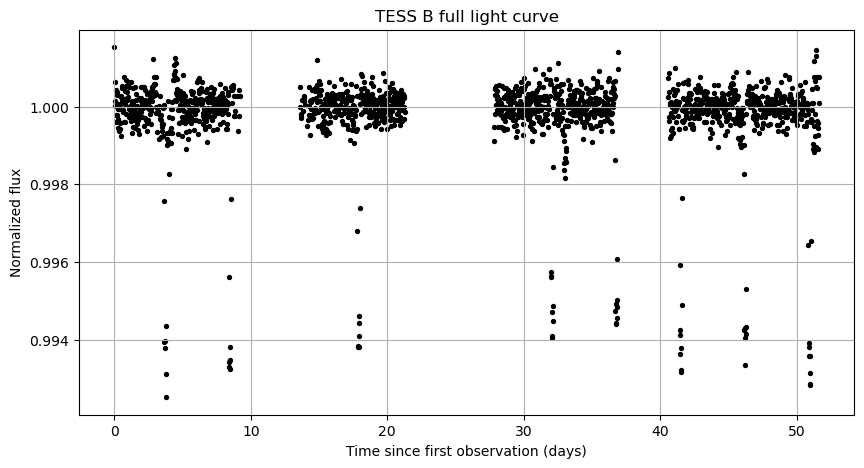

In [6]:
#visual look at full light curve
plt.figure()
plt.scatter(time, flux, s=8, color="black")
plt.xlabel("Time since first observation (days)")
plt.ylabel("Normalized flux")
plt.title("TESS B full light curve")
plt.show()

## 2. Light normalization

The file already contains detrended normalized flux, so the baseline should be near 1.  
However, a mild median-filter normalization is still useful for stabilizing the transit search against small local offsets.

This is **not** a heavy detrending procedure. It is only a light correction applied to an already detrended light curve.

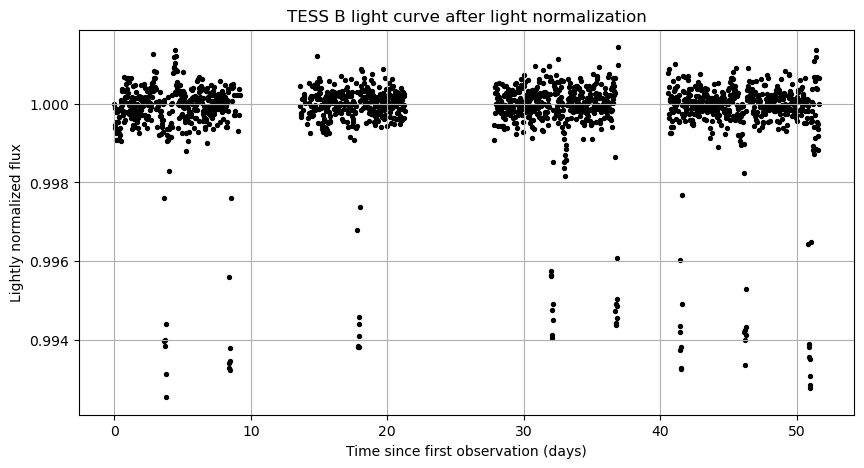

In [7]:
trend = median_filter(flux, size=101, mode="nearest")
flux_norm = flux / trend * np.median(trend)

plt.figure()
plt.scatter(time, flux_norm, s=8, color="black")
plt.xlabel("Time since first observation (days)")
plt.ylabel("Lightly normalized flux")
plt.title("TESS B light curve after light normalization")
plt.show()

## 3. Detect candidate transits

The transit signal appears as repeated dips in the light curve.
To get an initial estimate of the orbital period, I first search for deep local minima in the normalized flux.

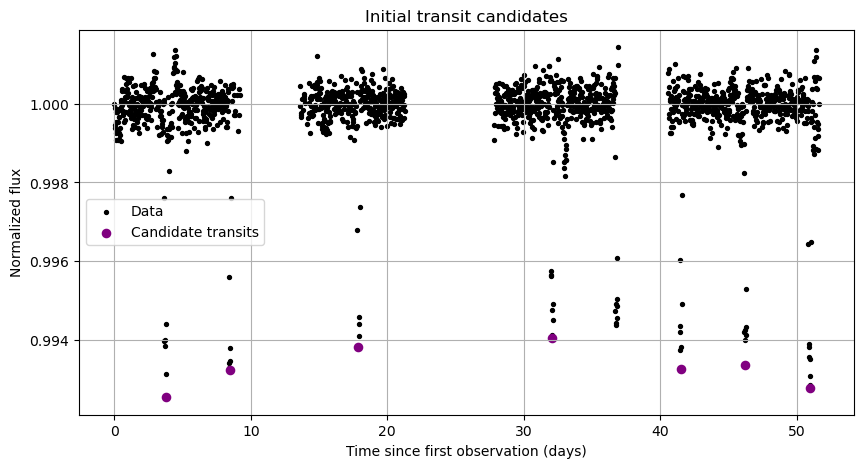

Initial candidate transit times (days):
[ 3.750171  8.479551 17.834171 32.046695 41.504992 46.234096 50.963189]


In [8]:
#initial transit search on inverted light curve
cadence = np.median(np.diff(time))
min_separation_days = 3.0
min_separation_points = int(min_separation_days / cadence)

peaks, peak_props = find_peaks(1.0 - flux_norm, prominence=0.002, distance=min_separation_points)

candidate_times = time[peaks]
candidate_fluxes = flux_norm[peaks]

plt.figure()
plt.scatter(time, flux_norm, s=8, color="black", label="Data")
plt.scatter(candidate_times, candidate_fluxes, s=35, color="Purple", label="Candidate transits")
plt.xlabel("Time since first observation (days)")
plt.ylabel("Normalized flux")
plt.title("Initial transit candidates")
plt.legend()
plt.show()

print("Initial candidate transit times (days):")
print(np.round(candidate_times, 6))

## 4. Refine the transit centers

To improve the transit timing measurements, each candidate dip is re-centered by fitting a quadratic curve to a few points around the local minimum.
This is not a full physical transit model, but it provides a better estimate of the time of minimum light than simply taking the lowest point.

In [9]:
def refine_transit_center_quadratic(t_window, f_window, points_each_side=2):
    imin = np.argmin(f_window)
    i0 = max(0, imin - points_each_side)
    i1 = min(len(t_window), imin + points_each_side + 1)

    t_fit = t_window[i0:i1]
    f_fit = f_window[i0:i1]

    if len(t_fit) < 3:
        return t_window[imin]

    a2, a1, a0 = np.polyfit(t_fit, f_fit, 2)
    if np.isclose(a2, 0.0):
        return t_window[imin]

    t_vertex = -a1 / (2 * a2)

    #if the fitted vertex falls outside local fitting window, fall back to minimum point
    if (t_vertex < t_fit.min()) or (t_vertex > t_fit.max()):
        return t_window[imin]

    return t_vertex


refined_centers = []
for t_guess in candidate_times:
    local = np.abs(time - t_guess) < 0.25
    refined_centers.append(refine_transit_center_quadratic(time[local], flux_norm[local]))

refined_centers = np.array(refined_centers)
print("Refined transit centers (days):")
print(np.round(refined_centers, 6))

Refined transit centers (days):
[ 3.748335  8.450155 17.866416 32.046695 41.514381 46.229221 50.964723]


## 5. Fit the orbital period from the transit centers

The observed transit centers follow

`t_n = t0 + nP`

To fit this relation, each transit is assigned an integer cycle number based on the approximate spacing between events.

Best-fit orbital period: 4.722675 ± 0.001883 days
Reference transit center t0: 3.725852 ± 0.012141 days


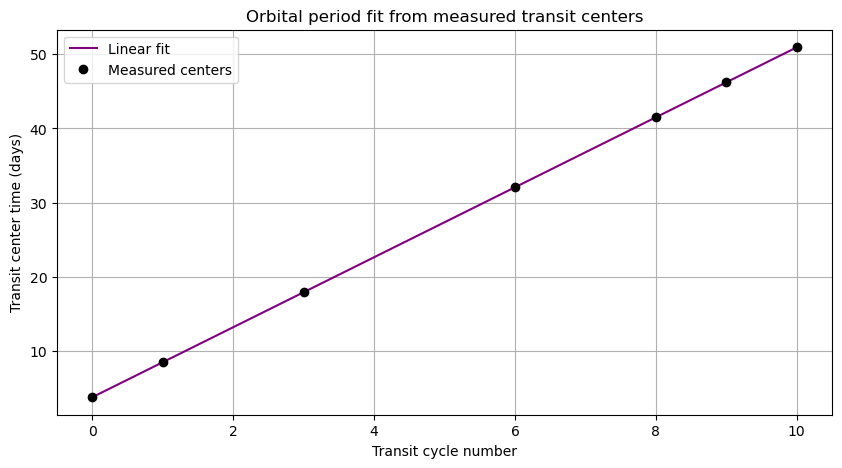

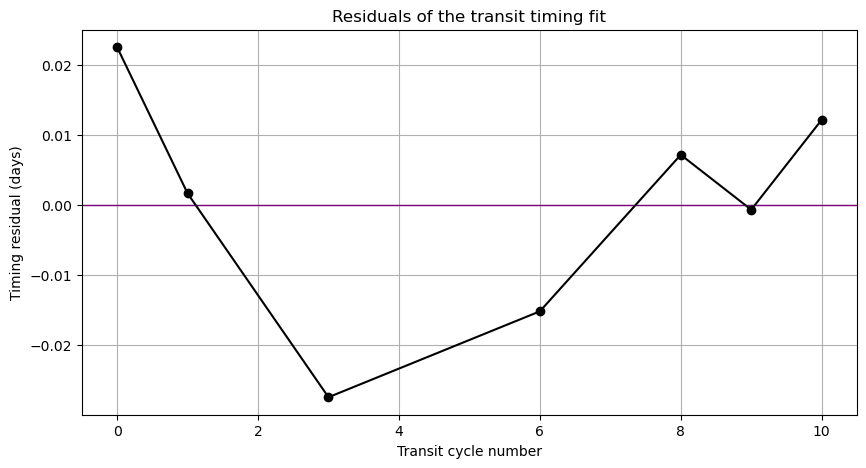

In [12]:
#assigns cycle numbers from the observed spacing
cycle_numbers = [0]
for dt in np.diff(refined_centers):
    cycle_numbers.append(cycle_numbers[-1] + round(dt / 4.72))
cycle_numbers = np.array(cycle_numbers)

#linear fit: t_n = t0 + nP
coeff = np.polyfit(cycle_numbers, refined_centers, 1)
period_days = coeff[0]
t0_days = coeff[1]

predicted_centers = np.polyval(coeff, cycle_numbers)
timing_residuals = refined_centers - predicted_centers

#standard error from linear regression
X = np.vstack([cycle_numbers, np.ones_like(cycle_numbers)]).T
cov = np.linalg.inv(X.T @ X) * np.sum(timing_residuals**2) / (len(cycle_numbers) - 2)
period_err_days = np.sqrt(cov[0, 0])
t0_err_days = np.sqrt(cov[1, 1])

print(f"Best-fit orbital period: {period_days:.6f} ± {period_err_days:.6f} days")
print(f"Reference transit center t0: {t0_days:.6f} ± {t0_err_days:.6f} days")

plt.figure()
plt.errorbar(cycle_numbers, refined_centers, yerr=None, fmt="o", color="black", label="Measured centers")
plt.plot(cycle_numbers, predicted_centers, color="purple", label="Linear fit")
plt.xlabel("Transit cycle number")
plt.ylabel("Transit center time (days)")
plt.title("Orbital period fit from measured transit centers")
plt.legend()
plt.show()

plt.figure()
plt.axhline(0, color="purple", lw=1)
plt.plot(cycle_numbers, timing_residuals, "o-", color="black")
plt.xlabel("Transit cycle number")
plt.ylabel("Timing residual (days)")
plt.title("Residuals of the transit timing fit")
plt.show()

## 6. Fold the light curve on the measured orbital period

Folding the light curve places all transits on top of one another so that the repeated signal can be studied more clearly.

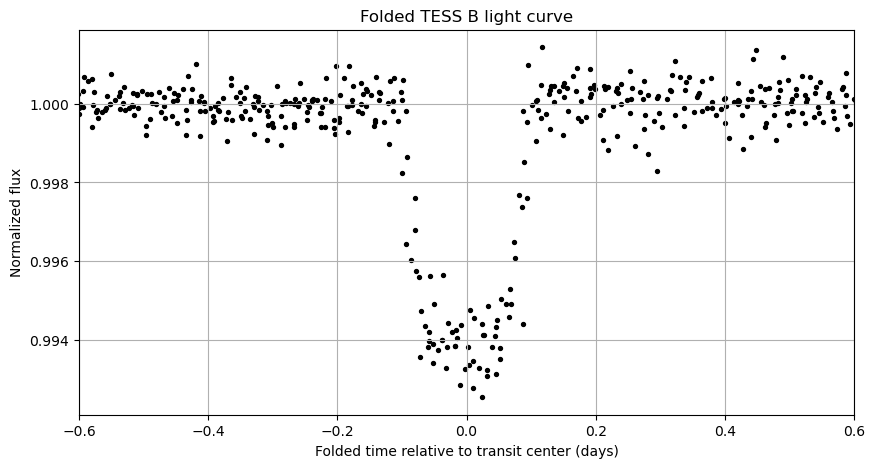

In [11]:
phase = ((time - t0_days + 0.5 * period_days) % period_days) - 0.5 * period_days

plt.figure()
plt.scatter(phase, flux_norm, s=8, color="black")
plt.xlim(-0.6, 0.6)
plt.xlabel("Folded time relative to transit center (days)")
plt.ylabel("Normalized flux")
plt.title("Folded TESS B light curve")
plt.show()

## 7. Box-transit characterization

A simplified box-shaped transit model is used to estimate:
- transit depth
- transit duration
- an optimized transit center and period

This is still a simplified model because it ignores limb darkening and detailed ingress/egress structure, but it is appropriate for a first-pass physical characterization.

In [14]:
def weighted_box_model(time_array, flux_array, err_array, P, t0, duration):
    phase_local = ((time_array - t0 + 0.5 * P) % P) - 0.5 * P
    in_transit = np.abs(phase_local) < duration / 2

    if in_transit.sum() < 5 or (~in_transit).sum() < 5:
        return np.nan, np.inf, in_transit, None, None

    weights = 1.0 / err_array**2
    out_flux = np.average(flux_array[~in_transit], weights=weights[~in_transit])
    in_flux = np.average(flux_array[in_transit], weights=weights[in_transit])

    depth = out_flux - in_flux

    model = np.full_like(flux_array, out_flux)
    model[in_transit] = out_flux - depth

    chi2 = np.sum(((flux_array - model) / err_array)**2)
    return depth, chi2, in_transit, model, phase_local


def objective_box(params):
    P, t0, duration = params
    if not (4.70 < P < 4.74):
        return np.inf
    if not (3.68 < t0 < 3.80):
        return np.inf
    if not (0.12 < duration < 0.25):
        return np.inf

    _, chi2, _, _, _ = weighted_box_model(time, flux_norm, flux_err, P, t0, duration)
    return chi2


result = differential_evolution(
    objective_box,
    bounds=[(4.70, 4.74), (3.68, 3.80), (0.12, 0.25)],
    seed=1,
    maxiter=25,
    popsize=12,
    polish=True
)

P_box, t0_box, duration_days = result.x
depth_frac, chi2_box, in_transit_mask, box_model_flux, phase_box = weighted_box_model(
    time, flux_norm, flux_err, P_box, t0_box, duration_days
)

print(f"Optimized box-model period: {P_box:.6f} days")
print(f"Optimized box-model t0: {t0_box:.6f} days")
print(f"Transit depth: {depth_frac:.6f}")
print(f"Transit duration: {duration_days:.6f} days")

Optimized box-model period: 4.721015 days
Optimized box-model t0: 3.731266 days
Transit depth: 0.005681
Transit duration: 0.169138 days


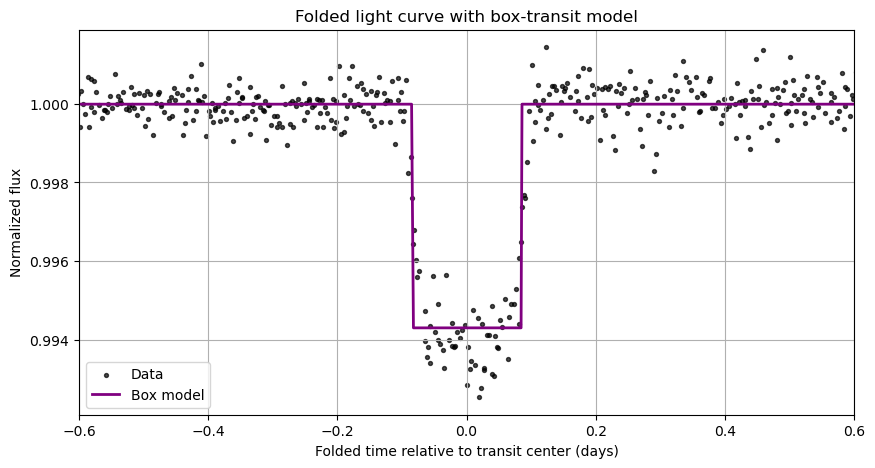

In [15]:
#plots folded light curve with box model
sort_idx = np.argsort(phase_box)

plt.figure()
plt.scatter(phase_box, flux_norm, s=8, color="black", alpha=0.7, label="Data")
plt.plot(phase_box[sort_idx], box_model_flux[sort_idx], color="purple", lw=2, label="Box model")
plt.xlim(-0.6, 0.6)
plt.xlabel("Folded time relative to transit center (days)")
plt.ylabel("Normalized flux")
plt.title("Folded light curve with box-transit model")
plt.legend()
plt.show()

## 8. Measure individual transit depths and durations

To obtain realistic uncertainties, I also estimate the depth and duration of the transits individually.
The final quoted depth and duration are based on the mean across measured transit events, with uncertainty taken from the standard error of the mean.

In [11]:
def estimate_single_transit_properties(time_array, flux_array, center_guess):
    window = np.abs(time_array - center_guess) < 0.4
    t_local = time_array[window]
    f_local = flux_array[window]

    if len(t_local) < 10:
        return np.nan, np.nan, np.nan

    #refinee local center
    center_local = refine_transit_center_quadratic(t_local, f_local, points_each_side=2)

    dt = t_local - center_local

    #estimates out-of-transit baseline and in-transit level
    out_region = (np.abs(dt) > 0.18) & (np.abs(dt) < 0.35)
    in_region = np.abs(dt) < 0.10

    if out_region.sum() < 5 or in_region.sum() < 5:
        return center_local, np.nan, np.nan

    baseline = np.median(f_local[out_region])
    transit_floor = np.median(f_local[in_region])
    depth = baseline - transit_floor

    #half-depth duration estimate by linear interpolation
    target = baseline - 0.5 * depth
    order = np.argsort(dt)
    dt = dt[order]
    ff = f_local[order]
    vals = ff - target

    left_cross = np.nan
    right_cross = np.nan

    for j in range(len(dt) - 1):
        if dt[j] < 0 and vals[j] * vals[j + 1] <= 0:
            left_cross = dt[j] - vals[j] * (dt[j + 1] - dt[j]) / (vals[j + 1] - vals[j])

    for j in range(len(dt) - 1):
        if dt[j] >= 0 and vals[j] * vals[j + 1] <= 0:
            right_cross = dt[j] - vals[j] * (dt[j + 1] - dt[j]) / (vals[j + 1] - vals[j])
            break

    duration = right_cross - left_cross if np.isfinite(left_cross) and np.isfinite(right_cross) else np.nan
    return center_local, depth, duration


#expected transit centers from period fit
n_max = int((time.max() - t0_days) / period_days) + 1
expected_centers = t0_days + np.arange(n_max + 1) * period_days
expected_centers = expected_centers[(expected_centers >= time.min()) & (expected_centers <= time.max())]

single_centers = []
single_depths = []
single_durations = []

for center_guess in expected_centers:
    c, d, dur = estimate_single_transit_properties(time, flux_norm, center_guess)
    if np.isfinite(c) and np.isfinite(d) and np.isfinite(dur):
        single_centers.append(c)
        single_depths.append(d)
        single_durations.append(dur)

single_centers = np.array(single_centers)
single_depths = np.array(single_depths)
single_durations = np.array(single_durations)

depth_mean = np.mean(single_depths)
depth_err = np.std(single_depths, ddof=1) / np.sqrt(len(single_depths))

duration_mean_days = np.mean(single_durations)
duration_err_days = np.std(single_durations, ddof=1) / np.sqrt(len(single_durations))

transit_table = pd.DataFrame({
    "transit_center_days": single_centers,
    "depth_fraction": single_depths,
    "duration_days": single_durations
})

transit_table

,transit_center_days,depth_fraction,duration_days
0,3.748335,0.005494,0.172002
1,8.450155,0.006456,0.164537
2,17.866416,0.005766,0.166864
3,32.046695,0.005143,0.168119
4,36.775788,0.005325,0.166712
5,41.514381,0.005793,0.169608
6,46.229221,0.005723,0.163622
7,50.964723,0.006440,0.170951


In [12]:
print(f"Final adopted period: {period_days:.6f} ± {period_err_days:.6f} days")
print(f"Final adopted depth: {depth_mean:.6f} ± {depth_err:.6f}")
print(f"Final adopted duration: {duration_mean_days:.6f} ± {duration_err_days:.6f} days")
print(f"Final adopted duration: {duration_mean_days * 24:.3f} ± {duration_err_days * 24:.3f} hours")

Final adopted period: 4.722675 ± 0.001883 days
Final adopted depth: 0.005767 ± 0.000168
Final adopted duration: 0.167802 ± 0.001045 days
Final adopted duration: 4.027 ± 0.025 hours


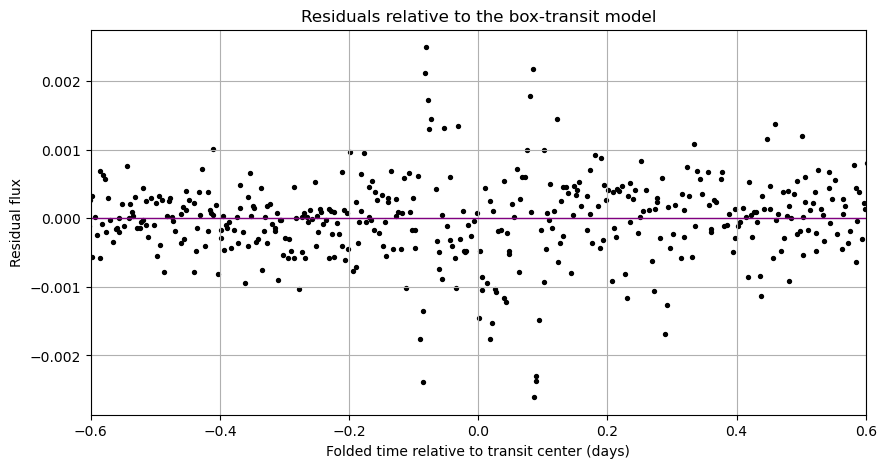

In [16]:
#residual analysis for box model
residuals = flux_norm - box_model_flux

plt.figure()
plt.scatter(phase_box, residuals, s=8, color="black")
plt.axhline(0, color="purple", lw=1)
plt.xlim(-0.6, 0.6)
plt.xlabel("Folded time relative to transit center (days)")
plt.ylabel("Residual flux")
plt.title("Residuals relative to the box-transit model")
plt.show()

## 9. Stellar parameters for TESS B

The host-star parameters are taken from the lab reference table:

- stellar temperature = `6274 ± 97 K`
- stellar radius = `1.925 ± 0.065 R_sun`
- stellar mass = `1.464 ± 0.080 M_sun`

These are used to estimate the planetary radius, orbital distance, orbital speed, transit probability, and equilibrium temperature.

In [14]:
#physical constants in cgs units
G = 6.67430e-8
M_sun = 1.98847e33
R_sun = 6.957e10
R_jup = 7.1492e9
AU = 1.495978707e13

#host star parameters for TESS B
T_star = 6274.0
T_star_err = 97.0

R_star_Rsun = 1.925
R_star_err_Rsun = 0.065

M_star_Msun = 1.464
M_star_err_Msun = 0.080

#adopted measured transit quantities
P_adopt = period_days
P_err = period_err_days

depth_adopt = depth_mean
depth_adopt_err = depth_err

duration_adopt_days = duration_mean_days
duration_adopt_err_days = duration_err_days

## 10. Monte Carlo uncertainty propagation

Rather than propagating errors by hand for every derived quantity, this project uses a Monte Carlo approach.
Random samples are drawn from the measured and stellar parameter uncertainties, and derived quantities are recomputed many times.

This gives uncertainties for:
- planet radius
- semi-major axis
- orbital speed
- transit probability
- equilibrium temperature
- orbital inclination

In [15]:
rng = np.random.default_rng(0)
N_mc = 100000

P_samples = rng.normal(P_adopt, P_err, N_mc)
depth_samples = np.clip(rng.normal(depth_adopt, depth_adopt_err, N_mc), 1e-8, None)
duration_samples = np.clip(rng.normal(duration_adopt_days, duration_adopt_err_days, N_mc), 1e-8, None)

R_star_samples = np.clip(rng.normal(R_star_Rsun, R_star_err_Rsun, N_mc), 1e-8, None)
M_star_samples = np.clip(rng.normal(M_star_Msun, M_star_err_Msun, N_mc), 1e-8, None)
T_star_samples = np.clip(rng.normal(T_star, T_star_err, N_mc), 1e-8, None)

P_sec_samples = P_samples * 86400.0
R_star_cm_samples = R_star_samples * R_sun
M_star_g_samples = M_star_samples * M_sun

#planet radius
R_p_cm_samples = np.sqrt(depth_samples) * R_star_cm_samples
R_p_Rj_samples = R_p_cm_samples / R_jup

#semi-major axis from kepler's third law
a_cm_samples = ((G * M_star_g_samples * P_sec_samples**2) / (4.0 * np.pi**2))**(1.0 / 3.0)
a_AU_samples = a_cm_samples / AU

#orbital speed
v_kms_samples = (2.0 * np.pi * a_cm_samples / P_sec_samples) / 1e5

#transit probability (approximation)
transit_probability_samples = R_star_cm_samples / a_cm_samples

#equilibrium temperature with albedo A = 0.4
A = 0.4
T_eq_samples = T_star_samples * np.sqrt(R_star_cm_samples / (2.0 * a_cm_samples)) * (1.0 - A)**0.25

#inclination from transit duration using small-planet circular approximation
x_samples = (duration_samples * 86400.0) * np.pi * a_cm_samples / (P_sec_samples * R_star_cm_samples)
valid = x_samples < 1.0
b_samples = np.sqrt(np.clip(1.0 - x_samples[valid]**2, 0.0, None))
cos_i_samples = np.clip(b_samples * R_star_cm_samples[valid] / a_cm_samples[valid], -1.0, 1.0)
inclination_deg_samples = np.degrees(np.arccos(cos_i_samples))

def summarize(samples):
    return np.mean(samples), np.std(samples, ddof=1)

Rp_Rj, Rp_Rj_err = summarize(R_p_Rj_samples)
a_AU, a_AU_err = summarize(a_AU_samples)
v_kms, v_kms_err = summarize(v_kms_samples)
p_transit, p_transit_err = summarize(transit_probability_samples)
T_eq, T_eq_err = summarize(T_eq_samples)
incl_deg, incl_deg_err = summarize(inclination_deg_samples)

print(f"Planet radius = {Rp_Rj:.3f} ± {Rp_Rj_err:.3f} R_J")
print(f"Semi-major axis = {a_AU:.5f} ± {a_AU_err:.5f} AU")
print(f"Orbital speed = {v_kms:.2f} ± {v_kms_err:.2f} km/s")
print(f"Transit probability = {p_transit:.3f} ± {p_transit_err:.3f}")
print(f"Equilibrium temperature = {T_eq:.0f} ± {T_eq_err:.0f} K")
print(f"Inclination = {incl_deg:.2f} ± {incl_deg_err:.2f} degrees")

Planet radius = 1.422 ± 0.052 R_J
Semi-major axis = 0.06254 ± 0.00114 AU
Orbital speed = 144.07 ± 2.63 km/s
Transit probability = 0.143 ± 0.006
Equilibrium temperature = 1477 ± 36 K
Inclination = 84.87 ± 0.51 degrees


## 11. Calculus 3: vector-valued orbital geometry

Using the measured orbital period and semi-major axis, the orbit can be represented as a vector-valued function

$$\mathbf{r}(t) = \langle x(t), y(t) \rangle$$

where

$$x(t) = a \cos(\omega t), \quad y(t) = a \sin(\omega t)$$
$$x(t) = a \cos(\omega t), \quad y(t) = a \sin(\omega t)$$

and

$$\omega = \frac{2\pi}{P}$$

To model the transit geometry, the orbit is projected onto the sky plane using the estimated inclination.

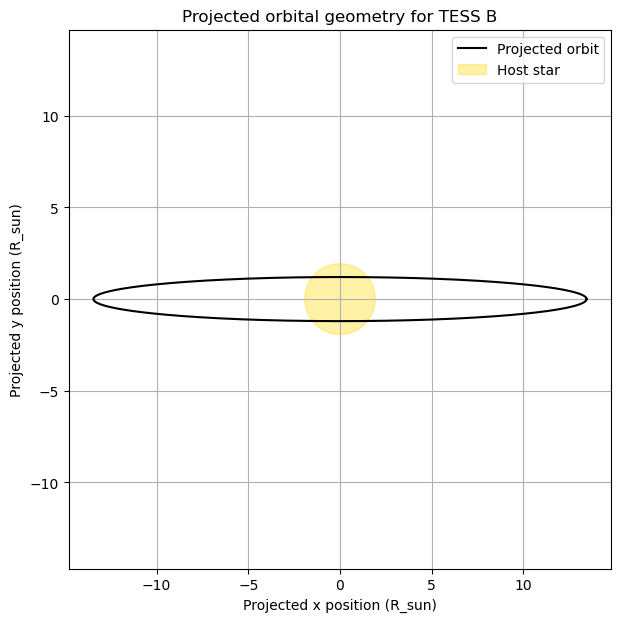

In [16]:
omega = 2.0 * np.pi / P_adopt
a_cm = a_AU * AU
incl_rad = np.radians(incl_deg)

t_orbit_days = np.linspace(0, P_adopt, 1000)
t_orbit_sec = t_orbit_days * 86400.0

x_orbit = a_cm * np.cos(omega * t_orbit_days)
y_orbit = a_cm * np.sin(omega * t_orbit_days)

#projects y-axis by inclination angle
y_projected = y_orbit * np.cos(incl_rad)

projected_separation = np.sqrt(x_orbit**2 + y_projected**2)

plt.figure(figsize=(7, 7))
plt.plot(x_orbit / R_sun, y_projected / R_sun, color="black", label="Projected orbit")
star = plt.Circle((0, 0), R_star_Rsun, color="gold", alpha=0.35, label="Host star")
plt.gca().add_patch(star)
plt.xlabel("Projected x position (R_sun)")
plt.ylabel("Projected y position (R_sun)")
plt.title("Projected orbital geometry for TESS B")
plt.axis("equal")
plt.legend(loc="upper right")
plt.show()

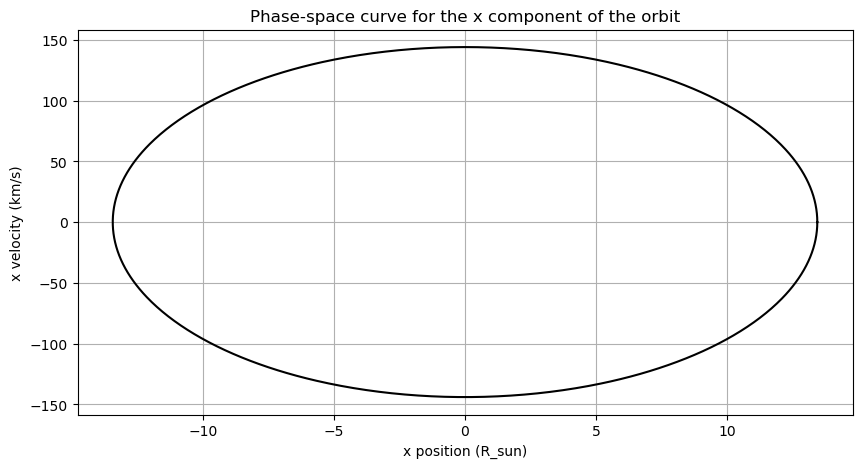

In [17]:
#phase-space style plot for x motion: x versus vx
vx_orbit = -a_cm * omega / 86400.0 * np.sin(omega * t_orbit_days)  #cm/s

plt.figure()
plt.plot(x_orbit / R_sun, vx_orbit / 1e5, color="black")
plt.xlabel("x position (R_sun)")
plt.ylabel("x velocity (km/s)")
plt.title("Phase-space curve for the x component of the orbit")
plt.show()

## 12. Calculus 4: solve the orbital differential equation with RK4

Now the same orbit is modeled as a solution to the gravitational system

$$\frac{dx}{dt} = v_x, \quad \frac{dy}{dt} = v_y$$
$$\frac{dv_x}{dt} = -\frac{G M_{\star} x}{r^3}, \quad 
\frac{dv_y}{dt} = -\frac{G M_{\star} y}{r^3}$$

where

$$r = \sqrt{x^2 + y^2}$$

This section numerically integrates the system using a fourth-order Runge-Kutta method.

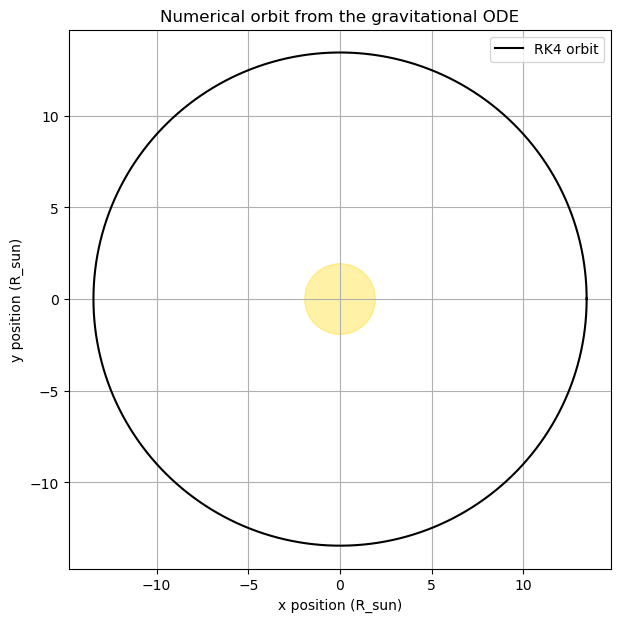

In [18]:
def derivatives(state, M_star_g):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    ax = -G * M_star_g * x / r**3
    ay = -G * M_star_g * y / r**3
    return np.array([vx, vy, ax, ay])


def rk4_step(state, dt, M_star_g):
    k1 = derivatives(state, M_star_g)
    k2 = derivatives(state + 0.5 * dt * k1, M_star_g)
    k3 = derivatives(state + 0.5 * dt * k2, M_star_g)
    k4 = derivatives(state + dt * k3, M_star_g)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


M_star_g = M_star_Msun * M_sun
P_sec = P_adopt * 86400.0

#initial state for an approximately circular orbit
x0 = a_cm
y0 = 0.0
vx0 = 0.0
vy0 = np.sqrt(G * M_star_g / a_cm)

state = np.array([x0, y0, vx0, vy0], dtype=float)

n_steps = 3000
dt = P_sec / n_steps

states = np.zeros((n_steps + 1, 4))
states[0] = state

for i in range(n_steps):
    state = rk4_step(state, dt, M_star_g)
    states[i + 1] = state

x_num = states[:, 0]
y_num = states[:, 1]

plt.figure(figsize=(7, 7))
plt.plot(x_num / R_sun, y_num / R_sun, color="black", label="RK4 orbit")
star = plt.Circle((0, 0), R_star_Rsun, color="gold", alpha=0.35)
plt.gca().add_patch(star)
plt.xlabel("x position (R_sun)")
plt.ylabel("y position (R_sun)")
plt.title("Numerical orbit from the gravitational ODE")
plt.axis("equal")
plt.legend()
plt.show()

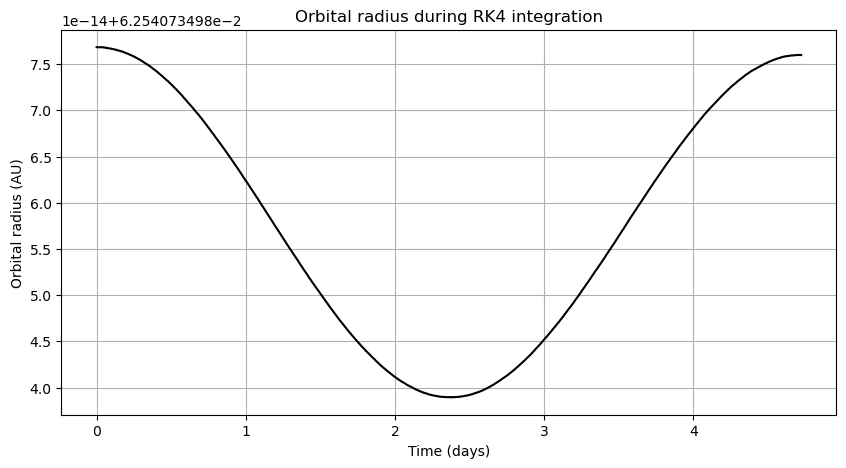

Mean RK4 orbital radius: 0.06254 AU
Standard deviation of RK4 orbital radius: 1.32538e-14 AU


In [19]:
#checks how well numerical orbit conserves radius for circular approximation
r_num = np.sqrt(x_num**2 + y_num**2)

plt.figure()
plt.plot(np.linspace(0, P_adopt, len(r_num)), r_num / AU, color="black")
plt.xlabel("Time (days)")
plt.ylabel("Orbital radius (AU)")
plt.title("Orbital radius during RK4 integration")
plt.show()

print(f"Mean RK4 orbital radius: {np.mean(r_num) / AU:.5f} AU")
print(f"Standard deviation of RK4 orbital radius: {np.std(r_num, ddof=1) / AU:.5e} AU")

## 13. Final results table

In [20]:
results_table = pd.DataFrame({
    "quantity": [
        "orbital period",
        "transit depth",
        "transit duration",
        "planet radius",
        "semi-major axis",
        "orbital speed",
        "transit probability",
        "equilibrium temperature",
        "orbital inclination"
    ],
    "value": [
        period_days,
        depth_mean,
        duration_mean_days * 24.0,
        Rp_Rj,
        a_AU,
        v_kms,
        p_transit,
        T_eq,
        incl_deg
    ],
    "uncertainty": [
        period_err_days,
        depth_err,
        duration_err_days * 24.0,
        Rp_Rj_err,
        a_AU_err,
        v_kms_err,
        p_transit_err,
        T_eq_err,
        incl_deg_err
    ],
    "units": [
        "days",
        "fraction",
        "hours",
        "R_J",
        "AU",
        "km/s",
        "dimensionless",
        "K",
        "degrees"
    ]
})

results_table

,quantity,value,uncertainty,units
0,orbital period,4.722675,0.001883,days
1,transit depth,0.005767,0.000168,fraction
2,transit duration,4.027243,0.025072,hours
3,planet radius,1.422462,0.052388,R_J
4,semi-major axis,0.062541,0.001142,AU
5,orbital speed,144.067719,2.629577,km/s
6,transit probability,0.143187,0.005511,dimensionless
7,equilibrium temperature,1477.210238,36.496265,K
8,orbital inclination,84.870561,0.513165,degrees


## 14. Interpretation

The TESS B light curve shows a clear sequence of repeated transits with an orbital period of about 4.72 days.  
The measured transit depth implies a planet radius of about 1.38 Jupiter radii, which places this object in the hot-Jupiter size range.  
The short orbital distance and high estimated equilibrium temperature are also consistent with a close-in giant planet.

The project is stronger than a simple transit-detection exercise because it goes beyond plotting the dips experienced in lab:
- the transit centers are measured and fit with a timing model
- the depth and duration are estimated from multiple events
- physical parameters are calculated using stellar properties
- vector geometry is used to interpret the transit configuration
- the orbit is also modeled as a solution to a gravitational differential equation

## 15. Limitations and future work

This project still uses a simplified transit treatment.

Main limitations:
- the transit is modeled as a box rather than a full limb-darkened light-curve model
- the inclination estimate assumes a circular orbit and the small-planet approximation
- stellar parameters are treated as independent Gaussian values in the Monte Carlo calculation
- no radial velocity data are used here, so the planet mass cannot be measured

Natural next steps:
- fit a physically motivated transit model with ingress and egress shape
- combine with radial velocity data to estimate planetary mass and density
- compare TESS B with the other TESS systems in the dataset set

## 16. Conclusion

Using the provided TESS B light curve, this project measured the main transit observables and converted them into astrophysically meaningful system parameters.
The final result is consistent with a short-period transiting giant planet.

This notebook also demonstrates how observational astrophysics connects directly to advanced mathematics:
- **Calculus 3** through vector-valued orbital geometry and projected separation
- **Calculus 4** through differential equations and numerical orbital integration